# 07 — Tier 3 Feature Evaluation: Zeo++ Geometric Descriptors

**What this does:**
1. Merges Zeo++ features (largest free sphere, POAV, density, etc.) with existing Tier 1 composition features
2. Trains XGBoost with and without Zeo++ features on the same subset (fair comparison)
3. Measures whether structural void geometry improves ionic conductivity prediction

**Zeo++ features extracted:**
- `largest_included_sphere`: diameter of biggest sphere that fits in any cavity
- `largest_free_sphere`: diameter of biggest sphere that can travel *through* the crystal (bottleneck)
- `largest_included_along_free`: largest sphere along the free sphere path
- `unitcell_volume`: volume of the unit cell (Å³)
- `density`: crystal density (g/cm³)
- `ponav_vol_frac`: probe non-accessible volume fraction (isolated pockets Li can fit in but not travel through)

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 1. Load and merge data

In [2]:
# UPDATE THESE PATHS
TRAIN_PATH = 'struct_train_features.csv'
TEST_PATH = 'struct_test_features.csv'
ZEO_PATH = 'zeo_features_v2.csv'

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
zeo = pd.read_csv(ZEO_PATH)

# Fix types
train['id'] = train['id'].astype(str)
test['id'] = test['id'].astype(str)
zeo['id'] = zeo['id'].astype(str)

# Convert bools to int
for df in [train, test]:
    for col in df.columns:
        if col not in ['id', 'composition']:
            df[col] = pd.to_numeric(df[col].replace({'True': 1, 'False': 0}), errors='coerce')

# Drop empty/useless zeo columns
zeo = zeo.drop(columns=['poav_vol_frac', 'poav_cm3g', 'ponav_cm3g'], errors='ignore')

# Drop rows where Zeo++ failed (no data)
zeo = zeo.dropna(subset=['largest_included_sphere'])

print(f'Train: {len(train)} entries')
print(f'Test: {len(test)} entries')
print(f'Zeo features: {len(zeo)} entries')

# Merge
train_merged = train.merge(zeo, on='id', how='inner')
test_merged = test.merge(zeo, on='id', how='inner')

print(f'\nAfter merge:')
print(f'Train: {len(train_merged)} (lost {len(train) - len(train_merged)} without Zeo++ data)')
print(f'Test: {len(test_merged)} (lost {len(test) - len(test_merged)} without Zeo++ data)')

Train: 339 entries
Test: 68 entries
Zeo features: 281 entries

After merge:
Train: 225 (lost 114 without Zeo++ data)
Test: 55 (lost 13 without Zeo++ data)


## 2. Define feature sets

In [3]:
# Tier 1 composition features (same as before)
tier1_features = [c for c in train.columns if c not in ['id', 'composition', 'log_conductivity']]

# Zeo++ structural features
zeo_features = [
    'largest_included_sphere',
    'largest_free_sphere',
    'largest_included_along_free',
    'unitcell_volume',
    'density',
    'ponav_vol_frac'
]

# Combined
all_features = tier1_features + zeo_features

print(f'Tier 1 features ({len(tier1_features)}): {tier1_features}')
print(f'Zeo features ({len(zeo_features)}): {zeo_features}')
print(f'Total features: {len(all_features)}')

Tier 1 features (16): ['li_count', 'mean_electronegativity', 'anion_electronegativity', 'cation_anion_en_diff', 'mean_ionic_radius', 'anion_ionic_radius', 'radius_std', 'anion_polarizability', 'mean_atomic_mass', 'n_elements', 'mean_atomic_number', 'anion_halide', 'anion_mixed', 'anion_other', 'anion_oxide', 'anion_sulfide']
Zeo features (6): ['largest_included_sphere', 'largest_free_sphere', 'largest_included_along_free', 'unitcell_volume', 'density', 'ponav_vol_frac']
Total features: 22


## 3. Prepare arrays

In [4]:
# Target
y_train = train_merged['log_conductivity'].values
y_test = test_merged['log_conductivity'].values

# Tier 1 only (on merged subset for fair comparison)
X_train_t1 = train_merged[tier1_features].values
X_test_t1 = test_merged[tier1_features].values

# Tier 1 + Zeo
X_train_all = train_merged[all_features].values
X_test_all = test_merged[all_features].values

print(f'Tier 1 shape: {X_train_t1.shape}')
print(f'Tier 1 + Zeo shape: {X_train_all.shape}')
print(f'Target range: [{y_train.min():.2f}, {y_train.max():.2f}]')

Tier 1 shape: (225, 16)
Tier 1 + Zeo shape: (225, 22)
Target range: [-16.80, -1.61]


## 4. Train and compare

In [5]:
# --- Model 1: Tier 1 only, default XGBoost ---
m1 = xgb.XGBRegressor(random_state=42, n_estimators=100)
m1.fit(X_train_t1, y_train)
p1 = m1.predict(X_test_t1)
mae1 = mean_absolute_error(y_test, p1)
r2_1 = r2_score(y_test, p1)

# --- Model 2: Tier 1 + Zeo, default XGBoost ---
m2 = xgb.XGBRegressor(random_state=42, n_estimators=100)
m2.fit(X_train_all, y_train)
p2 = m2.predict(X_test_all)
mae2 = mean_absolute_error(y_test, p2)
r2_2 = r2_score(y_test, p2)

# --- Model 3: Tier 1 + Zeo, conservative tuned XGBoost ---
m3 = xgb.XGBRegressor(
    n_estimators=400, max_depth=4, learning_rate=0.03,
    min_child_weight=7, subsample=0.8, colsample_bytree=0.6,
    reg_lambda=5, reg_alpha=0.5, random_state=42
)
m3.fit(X_train_all, y_train)
p3 = m3.predict(X_test_all)
mae3 = mean_absolute_error(y_test, p3)
r2_3 = r2_score(y_test, p3)

print('=' * 60)
print(f'Tier 1 only (default XGB)    | MAE: {mae1:.4f} | R²: {r2_1:.4f}')
print(f'Tier 1 + Zeo (default XGB)   | MAE: {mae2:.4f} | R²: {r2_2:.4f}')
print(f'Tier 1 + Zeo (tuned XGB)     | MAE: {mae3:.4f} | R²: {r2_3:.4f}')
print('=' * 60)
print(f'Zeo improvement (default):     {mae1 - mae2:.4f} ({(mae1 - mae2) / mae1 * 100:.1f}%)')
print(f'\nFor reference:')
print(f'  OBELiX RF baseline:          1.54')
print(f'  Your comp-only (full 829):   1.144')
print(f'  Chung GBR (diff dataset):    0.543')
print(f'  Noise floor:                 0.41')

Tier 1 only (default XGB)    | MAE: 1.7428 | R²: 0.3753
Tier 1 + Zeo (default XGB)   | MAE: 1.5499 | R²: 0.4461
Tier 1 + Zeo (tuned XGB)     | MAE: 1.6883 | R²: 0.3385
Zeo improvement (default):     0.1928 (11.1%)

For reference:
  OBELiX RF baseline:          1.54
  Your comp-only (full 829):   1.144
  Chung GBR (diff dataset):    0.543
  Noise floor:                 0.41


In [ ]:
#RETUNING OPTUNA HYPERPARAMS TO SEE IF MAE IMPROVES

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import cross_val_score, KFold

def objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 50, 800),
        'max_depth':       trial.suggest_int('max_depth', 2, 8),
        'learning_rate':   trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample':       trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'min_child_weight':trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha':       trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':      trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma':           trial.suggest_float('gamma', 0, 5.0),
        'random_state':    42,
    }
    model = xgb.XGBRegressor(**params)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_all, y_train, cv=kf, scoring='neg_mean_absolute_error')
    return -scores.mean()

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f'Best CV MAE: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

# Evaluate on test set
m4 = xgb.XGBRegressor(**{**study.best_params, 'random_state': 42})
m4.fit(X_train_all, y_train)
p4 = m4.predict(X_test_all)
mae4 = mean_absolute_error(y_test, p4)
r2_4 = r2_score(y_test, p4)

print(f'\n{"=" * 60}')
print(f'Tier 1 only (default XGB)        | MAE: {mae1:.4f} | R²: {r2_1:.4f}')
print(f'Tier 1 + Zeo (default XGB)       | MAE: {mae2:.4f} | R²: {r2_2:.4f}')
print(f'Tier 1 + Zeo (Optuna tuned XGB)  | MAE: {mae4:.4f} | R²: {r2_4:.4f}')
print(f'{"=" * 60}')

  0%|          | 0/200 [00:00<?, ?it/s]

Best CV MAE: 1.1440
Best params: {'n_estimators': 706, 'max_depth': 7, 'learning_rate': 0.016470460610987822, 'subsample': 0.988904485885594, 'colsample_bytree': 0.32840043743027986, 'min_child_weight': 1, 'reg_alpha': 0.003262584830699865, 'reg_lambda': 0.13009617916918992, 'gamma': 0.0009516471349892246}

Tier 1 only (default XGB)        | MAE: 1.7428 | R²: 0.3753
Tier 1 + Zeo (default XGB)       | MAE: 1.5499 | R²: 0.4461
Tier 1 + Zeo (Optuna tuned XGB)  | MAE: 1.5823 | R²: 0.3973


In [12]:
# === DIAGNOSIS: Is it data loss or feature noise? ===

# Test A: Tier 1 on original 339/68 vs merged 225/55
m_full = xgb.XGBRegressor(random_state=42, n_estimators=100)
X_tr_full = train[[c for c in train.columns if c not in ['id','composition','log_conductivity']]]
for col in X_tr_full.columns:
    X_tr_full[col] = pd.to_numeric(X_tr_full[col].replace({'True':1,'False':0}), errors='coerce')
X_te_full = test[[c for c in test.columns if c not in ['id','composition','log_conductivity']]]
for col in X_te_full.columns:
    X_te_full[col] = pd.to_numeric(X_te_full[col].replace({'True':1,'False':0}), errors='coerce')

m_full.fit(X_tr_full, train['log_conductivity'])
p_full = m_full.predict(X_te_full)
mae_full = mean_absolute_error(test['log_conductivity'], p_full)

print("=== Diagnosis: Data loss vs Feature noise ===")
print(f"Tier 1 on full 339/68:          MAE={mae_full:.4f}")
print(f"Tier 1 on merged 225/55:        MAE={mae1:.4f}")
print(f"Tier 1 + Zeo on merged 225/55:  MAE={mae2:.4f}")
print(f"")
print(f"MAE increase from data loss:    {mae1 - mae_full:.4f}")
print(f"MAE decrease from Zeo features: {mae1 - mae2:.4f}")

=== Diagnosis: Data loss vs Feature noise ===
Tier 1 on full 339/68:          MAE=1.5347
Tier 1 on merged 225/55:        MAE=1.7428
Tier 1 + Zeo on merged 225/55:  MAE=1.5499

MAE increase from data loss:    0.2081
MAE decrease from Zeo features: 0.1928


In [13]:
# Test B: Only the best Zeo features (drop the noisy ones)
slim_zeo = ['largest_free_sphere', 'density', 'unitcell_volume']
slim_features = tier1_features + slim_zeo

m_slim = xgb.XGBRegressor(random_state=42, n_estimators=100)
m_slim.fit(train_merged[slim_features], y_train)
p_slim = m_slim.predict(test_merged[slim_features])
mae_slim = mean_absolute_error(y_test, p_slim)

print(f"\n=== Diagnosis: Feature selection ===")
print(f"All 6 Zeo features:             MAE={mae2:.4f}")
print(f"Best 3 Zeo features only:       MAE={mae_slim:.4f}")
print(f"Slim features: {slim_features}")


=== Diagnosis: Feature selection ===
All 6 Zeo features:             MAE=1.5499
Best 3 Zeo features only:       MAE=1.6150
Slim features: ['li_count', 'mean_electronegativity', 'anion_electronegativity', 'cation_anion_en_diff', 'mean_ionic_radius', 'anion_ionic_radius', 'radius_std', 'anion_polarizability', 'mean_atomic_mass', 'n_elements', 'mean_atomic_number', 'anion_halide', 'anion_mixed', 'anion_other', 'anion_oxide', 'anion_sulfide', 'largest_free_sphere', 'density', 'unitcell_volume']


## 5. Feature importance

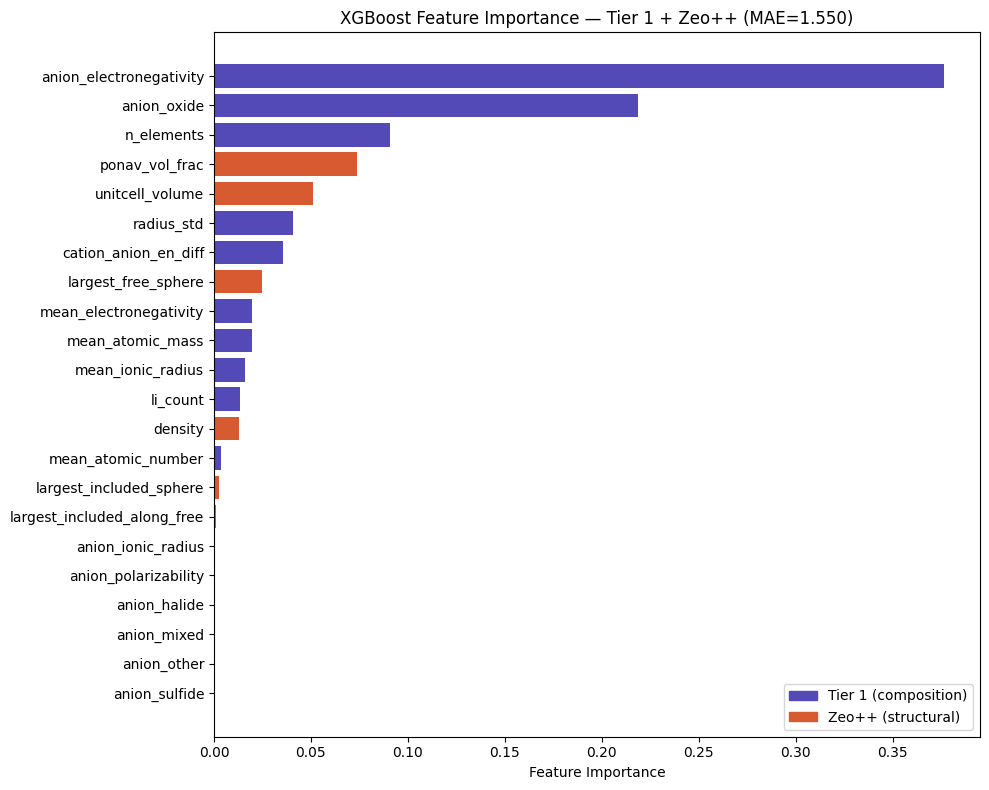

Feature importance (ranked):
  anion_electronegativity        0.3763
  anion_oxide                    0.2185
  n_elements                     0.0906
  ponav_vol_frac                 0.0739 <-- ZEO
  unitcell_volume                0.0509 <-- ZEO
  radius_std                     0.0405
  cation_anion_en_diff           0.0356
  largest_free_sphere            0.0246 <-- ZEO
  mean_electronegativity         0.0198
  mean_atomic_mass               0.0194
  mean_ionic_radius              0.0159
  li_count                       0.0135
  density                        0.0129 <-- ZEO
  mean_atomic_number             0.0034
  largest_included_sphere        0.0026 <-- ZEO
  largest_included_along_free    0.0011 <-- ZEO
  anion_ionic_radius             0.0003
  anion_polarizability           0.0000
  anion_halide                   0.0000
  anion_mixed                    0.0000
  anion_other                    0.0000
  anion_sulfide                  0.0000


In [6]:
# Use whichever model performed best
best_model = m2 if mae2 <= mae3 else m3
best_preds = p2 if mae2 <= mae3 else p3
best_mae = min(mae2, mae3)

importances = best_model.feature_importances_
feat_imp = sorted(zip(all_features, importances), key=lambda x: x[1], reverse=True)

# Color Zeo features differently
names = [f for f, _ in feat_imp]
vals = [v for _, v in feat_imp]
colors = ['#D85A30' if f in zeo_features else '#534AB7' for f in names]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(names)), vals, color=colors)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance')
ax.set_title(f'XGBoost Feature Importance — Tier 1 + Zeo++ (MAE={best_mae:.3f})')

# Legend
from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(color='#534AB7', label='Tier 1 (composition)'),
             Patch(color='#D85A30', label='Zeo++ (structural)')],
    loc='lower right'
)
plt.tight_layout()
plt.show()

print('Feature importance (ranked):')
for fname, imp in feat_imp:
    tag = ' <-- ZEO' if fname in zeo_features else ''
    print(f'  {fname:30s} {imp:.4f}{tag}')

## 6. Residual analysis

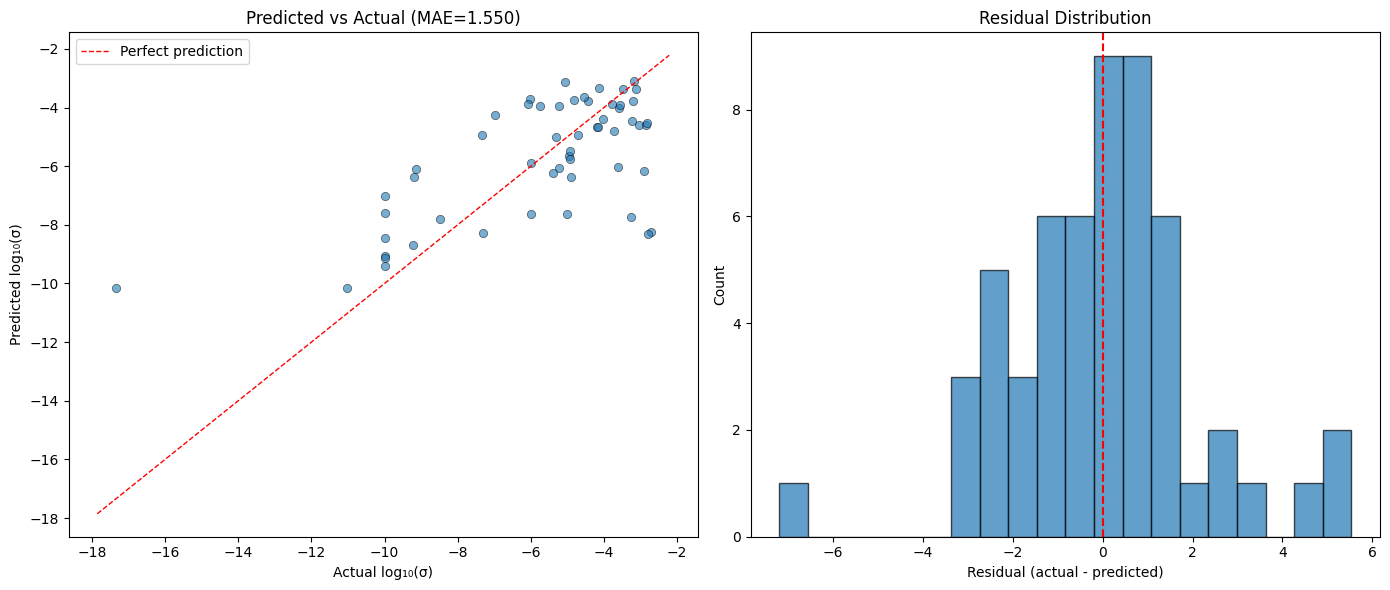

In [7]:
residuals = y_test - best_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Predicted vs actual
ax = axes[0]
ax.scatter(y_test, best_preds, alpha=0.6, edgecolors='k', linewidth=0.5)
lims = [min(y_test.min(), best_preds.min()) - 0.5,
        max(y_test.max(), best_preds.max()) + 0.5]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual log₁₀(σ)')
ax.set_ylabel('Predicted log₁₀(σ)')
ax.set_title(f'Predicted vs Actual (MAE={best_mae:.3f})')
ax.legend()

# Residual histogram
ax = axes[1]
ax.hist(residuals, bins=20, edgecolor='k', alpha=0.7)
ax.axvline(0, color='r', linestyle='--')
ax.set_xlabel('Residual (actual - predicted)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution')

plt.tight_layout()
plt.show()

In [8]:
# Worst predictions
results = test_merged[['id', 'composition', 'log_conductivity']].copy()
results['predicted'] = best_preds
results['abs_error'] = np.abs(residuals)

worst = results.nlargest(10, 'abs_error')

print('Worst 10 predictions:')
print(f'{"Composition":25s} {"Actual":>8s} {"Predicted":>10s} {"Error":>8s}')
print('-' * 55)
for _, row in worst.iterrows():
    print(f'{row["composition"]:25s} {row["log_conductivity"]:8.2f} '
          f'{row["predicted"]:10.2f} {row["abs_error"]:8.2f}')

Worst 10 predictions:
Composition                 Actual  Predicted    Error
-------------------------------------------------------
Li2NaBP2O8                  -17.36     -10.17     7.18
Li3YBr6                      -2.72      -8.25     5.53
LiTa2PO8                     -2.80      -8.31     5.51
Li3YCl6                      -3.27      -7.74     4.47
Li6.05Ga0.25La3Zr2O11.8F0.2    -2.89      -6.16     3.27
La(Li0.76Mg0.08)O2           -9.14      -6.11     3.03
LaLiO2                      -10.00      -7.01     2.99
(La0.9Sr0.1)LiO2             -9.20      -6.37     2.84
(La0.7Li0.3)(Ti0.6Al0.4)O3    -6.98      -4.26     2.72
Li0.4Na0.1La0.5Nb2O6         -5.00      -7.63     2.63


## 7. Zeo++ feature distributions

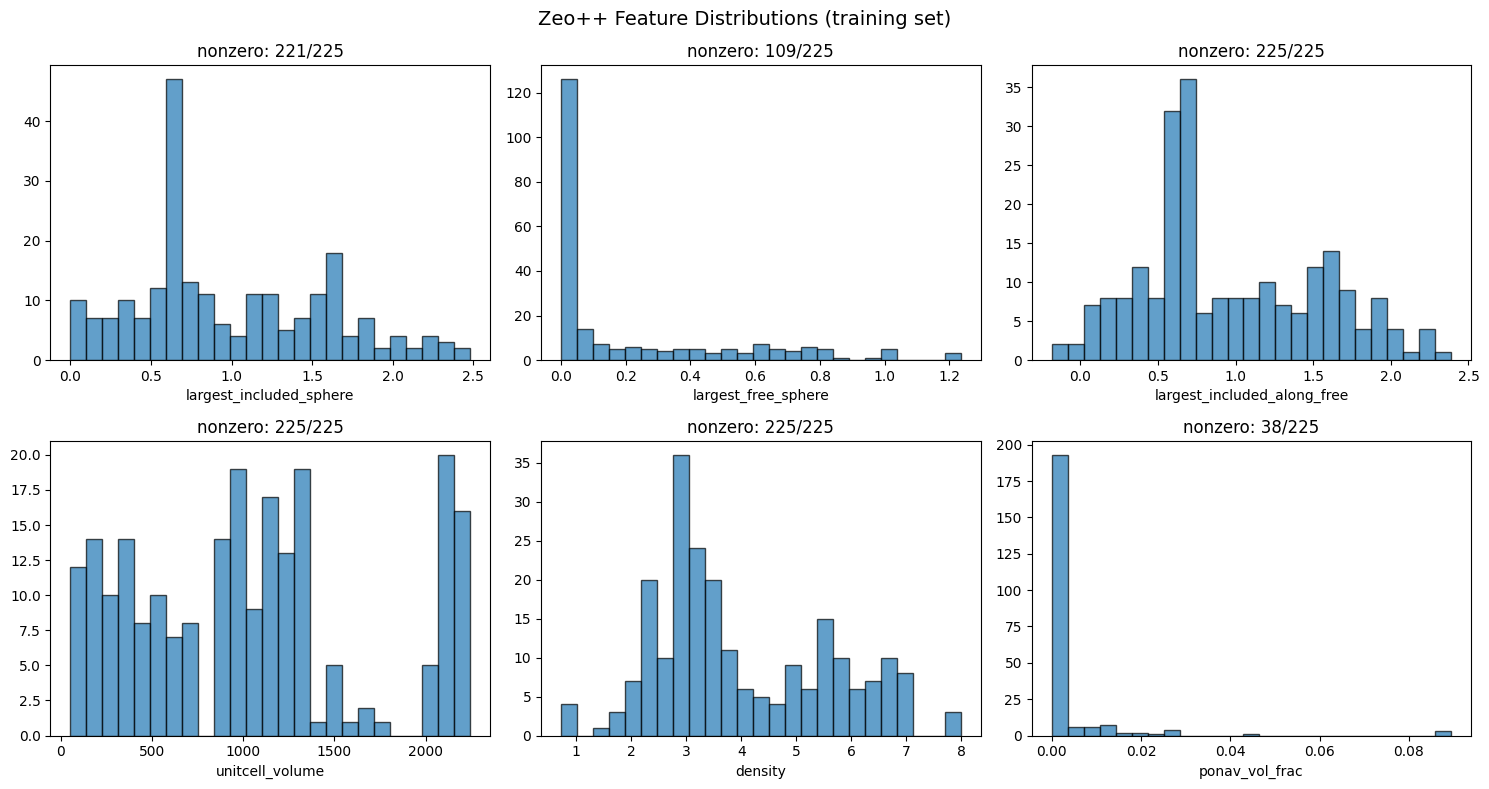

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feat in zip(axes.flat, zeo_features):
    vals = train_merged[feat]
    ax.hist(vals, bins=25, edgecolor='k', alpha=0.7)
    ax.set_xlabel(feat)
    ax.set_title(f'nonzero: {int((vals != 0).sum())}/{len(vals)}')

plt.suptitle('Zeo++ Feature Distributions (training set)', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Correlation of Zeo++ features with target
print('Correlation with log_conductivity:')
for feat in zeo_features:
    corr = train_merged[feat].corr(train_merged['log_conductivity'])
    print(f'  {feat:30s} {corr:+.3f}')

Correlation with log_conductivity:
  largest_included_sphere        -0.005
  largest_free_sphere            -0.137
  largest_included_along_free    -0.005
  unitcell_volume                +0.366
  density                        +0.104
  ponav_vol_frac                 -0.033
